# 模型批量验证对比 Notebook

本 Notebook 用于在 **train / valid / test** 三个数据集上系统性对比微调模型与原始模型的检测性能。

## 评估维度
1. **数值量化指标**: IOU、精确率(Precision)、召回率(Recall)、F1分数、检测准确率
2. **跨数据集对比**: 在 train / valid / test 上分别评估，观察泛化能力
3. **可视化对比**: 指标雷达图、分组柱状图、差异热力图
4. **差异分析**: 自动识别关键差异点并生成简要分析

---

## 0. 环境配置

In [ ]:
import json
import os
import re
import sys
import time
import warnings
from collections import Counter, defaultdict
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np

warnings.filterwarnings("ignore")

try:
    from io import BytesIO

    import matplotlib.patches as mpatches
    import matplotlib.pyplot as plt
    import requests
    import torch
    from matplotlib.gridspec import GridSpec
    from PIL import Image, ImageDraw, ImageFont

    if hasattr(__builtins__, "__IPYTHON__"):
        from tqdm.notebook import tqdm
    else:
        from tqdm import tqdm

    import matplotlib.font_manager as fm
    chinese_fonts = ['SimHei', 'Microsoft YaHei', 'PingFang SC', 'Heiti SC', 'STHeiti', 'WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'Source Han Sans SC']
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    font_found = None
    for font_name in chinese_fonts:
        if font_name in available_fonts:
            font_found = font_name
            break
    if font_found:
        plt.rcParams['font.sans-serif'] = [font_found, 'DejaVu Sans']
        plt.rcParams['axes.unicode_minus'] = False
    else:
        print('警告: 未找到中文字体, 图表中文可能显示为方块')
        plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

    print("依赖加载成功")
    print(f"PyTorch版本: {torch.__version__}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"GPU内存: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
except ImportError as e:
    print(f"缺少依赖: {e}")
    print("请安装: pip install torch pillow matplotlib requests numpy")
    sys.exit(1)

依赖加载成功
PyTorch版本: 2.10.0+cu128
GPU: NVIDIA RTX 5880 Ada Generation
GPU内存: 47.4 GB


## 1. 评估指标模块

包含 IOU 计算器（边界框重叠度）和检测指标计算器（精确率/召回率/F1等）。

In [2]:
class IOUCalculator:
    """IOU(交并比)计算器"""

    @staticmethod
    def calculate_iou(box1: List[float], box2: List[float]) -> float:
        """计算两个边界框的IOU, bbox格式: [x1, y1, x2, y2]"""
        x1_1, y1_1, x2_1, y2_1 = box1
        x1_2, y1_2, x2_2, y2_2 = box2

        xi1 = max(x1_1, x1_2)
        yi1 = max(y1_1, y1_2)
        xi2 = min(x2_1, x2_2)
        yi2 = min(y2_1, y2_2)

        if xi2 <= xi1 or yi2 <= yi1:
            return 0.0

        inter_area = (xi2 - xi1) * (yi2 - yi1)
        box1_area = (x2_1 - x1_1) * (y2_1 - y1_1)
        box2_area = (x2_2 - x1_2) * (y2_2 - y1_2)
        union_area = box1_area + box2_area - inter_area

        return inter_area / union_area if union_area > 0 else 0.0

    @staticmethod
    def calculate_batch_iou(detections1: List[Dict], detections2: List[Dict]) -> Dict[str, Any]:
        """批量计算两组检测结果的IOU"""
        if not detections1 or not detections2:
            return {
                "mean_iou": 0.0,
                "max_iou": 0.0,
                "min_iou": 0.0,
                "num_pairs": 0,
                "class_ious": {},
            }

        all_ious = []
        class_ious = {}

        for det1 in detections1:
            bbox1 = det1.get("bbox", [0, 0, 0, 0])
            label1 = det1.get("label", "unknown")

            best_iou = 0.0
            for det2 in detections2:
                bbox2 = det2.get("bbox", [0, 0, 0, 0])
                iou = IOUCalculator.calculate_iou(bbox1, bbox2)
                best_iou = max(best_iou, iou)

            if best_iou > 0:
                all_ious.append(best_iou)
                if label1 not in class_ious:
                    class_ious[label1] = []
                class_ious[label1].append(best_iou)

        class_stats = {}
        for label, ious in class_ious.items():
            class_stats[label] = {
                "mean_iou": np.mean(ious),
                "max_iou": np.max(ious),
                "min_iou": np.min(ious),
                "count": len(ious),
            }

        return {
            "mean_iou": float(np.mean(all_ious)) if all_ious else 0.0,
            "max_iou": float(np.max(all_ious)) if all_ious else 0.0,
            "min_iou": float(np.min(all_ious)) if all_ious else 0.0,
            "num_pairs": len(all_ious),
            "class_ious": class_stats,
        }

    @staticmethod
    def filter_by_confidence(detections: List[Dict], threshold: float) -> List[Dict]:
        """根据置信度阈值过滤检测结果"""
        return [det for det in detections if det.get("confidence", 0) >= threshold]


class MetricsCalculator:
    """检测评估指标计算器

    通过IOU匹配计算精确率、召回率、F1等指标。
    匹配策略: 对每个检测结果找最佳IOU的ground truth, IOU >= threshold 则视为匹配。
    """

    DEFAULT_IOU_THRESHOLD = 0.5

    @staticmethod
    def compute_sample_metrics(
        detections: List[Dict],
        ground_truth: List[Dict],
        iou_threshold: float = 0.5,
    ) -> Dict[str, Any]:
        """计算单样本的检测指标"""
        if not ground_truth:
            if not detections:
                return {
                    "precision": 1.0,
                    "recall": 1.0,
                    "f1": 1.0,
                    "num_det": 0,
                    "num_gt": 0,
                    "num_match": 0,
                    "mean_match_iou": 0.0,
                    "det_success": True,
                }
            return {
                "precision": 0.0,
                "recall": 1.0,
                "f1": 0.0,
                "num_det": len(detections),
                "num_gt": 0,
                "num_match": 0,
                "mean_match_iou": 0.0,
                "det_success": False,
            }

        if not detections:
            return {
                "precision": 1.0,
                "recall": 0.0,
                "f1": 0.0,
                "num_det": 0,
                "num_gt": len(ground_truth),
                "num_match": 0,
                "mean_match_iou": 0.0,
                "det_success": False,
            }

        matched_gt = set()
        matched_det = set()
        match_ious = []

        for i, det in enumerate(detections):
            det_bbox = det.get("bbox", [0, 0, 0, 0])
            best_iou = 0.0
            best_j = -1
            for j, gt in enumerate(ground_truth):
                if j in matched_gt:
                    continue
                gt_bbox = gt.get("bbox", [0, 0, 0, 0])
                iou = IOUCalculator.calculate_iou(det_bbox, gt_bbox)
                if iou > best_iou:
                    best_iou = iou
                    best_j = j
            if best_iou >= iou_threshold and best_j >= 0:
                matched_gt.add(best_j)
                matched_det.add(i)
                match_ious.append(best_iou)

        precision = len(matched_det) / len(detections)
        recall = len(matched_gt) / len(ground_truth)
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        det_success = len(matched_gt) == len(ground_truth) and len(matched_det) == len(detections)

        return {
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "num_det": len(detections),
            "num_gt": len(ground_truth),
            "num_match": len(matched_det),
            "mean_match_iou": float(np.mean(match_ious)) if match_ious else 0.0,
            "det_success": det_success,
        }

    @staticmethod
    def aggregate_metrics(sample_metrics_list: List[Dict]) -> Dict[str, Any]:
        """汇总多个样本的指标, 计算均值和标准差"""
        if not sample_metrics_list:
            return {}

        keys = ["precision", "recall", "f1", "num_det", "num_gt", "num_match", "mean_match_iou"]
        result = {}
        for key in keys:
            values = [m[key] for m in sample_metrics_list if key in m]
            if values:
                result[f"mean_{key}"] = float(np.mean(values))
                result[f"std_{key}"] = float(np.std(values))
            else:
                result[f"mean_{key}"] = 0.0
                result[f"std_{key}"] = 0.0

        result["total_samples"] = len(sample_metrics_list)
        result["success_rate"] = float(np.mean([m.get("det_success", False) for m in sample_metrics_list]))

        # 计算宏平均(macro-average): 先按类别分组计算, 再取平均
        return result


print("IOU计算器和指标计算器已初始化")

IOU计算器和指标计算器已初始化


## 2. 配置参数

修改以下配置单元格中的参数即可适配不同环境。所有路径基于 `PROJECT_ROOT` 自动推导。

**跨Notebook参数关联:**
- `BASE_MODEL_PATH`: 与 **02-微调** 和 **03-推理** Notebook 中的基础模型路径保持一致
- `LORA_ADAPTER_PATH`: 由 **02-微调** Notebook 生成的 LoRA 适配器路径
- `DATA_DIR`: 由 **01-数据预处理** Notebook 生成的 JSONL 数据目录

In [3]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()

_nb_file = globals().get("__vsc_ipynb_file__", "")
_search_starts = [NOTEBOOK_DIR] + ([Path(_nb_file).parent] if _nb_file else [])
PROJECT_ROOT = None
for _s in _search_starts:
    for _p in [_s] + list(_s.parents):
        if (_p / "pyproject.toml").exists():
            PROJECT_ROOT = _p
            break
    if PROJECT_ROOT:
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = NOTEBOOK_DIR.parent

# ---------- 模型路径配置 ----------
BASE_MODEL_PATH = "/raid5/sh/model/unsloth/gemma-4-E4B-it-unsloth-bnb-4bit"
LORA_ADAPTER_PATH = str(PROJECT_ROOT / "models" / "finetuned" / "gemma4_e4b_lora" / "single/20260514_051604")

# ---------- 数据集路径配置 ----------
# 由01-数据预处理Notebook生成的JSONL数据目录
DATA_DIR = str(PROJECT_ROOT / "data" / "processed" / "unsloth_training_data-wgang_40")
# 加载三个数据集
data_dir = Path(DATA_DIR)
split_files = {
    # "train": data_dir / "train.jsonl",
    # "valid": data_dir / "val.jsonl",
    "test": data_dir
    / "test.jsonl",
}


# ---------- 模型加载参数 ----------
MAX_SEQ_LENGTH = 2048
LOAD_IN_4BIT = True
DEVICE_MAP = "balanced"

# ---------- 推理参数 ----------
INFERENCE_MAX_NEW_TOKENS = 512
INFERENCE_TEMPERATURE = 0.7
INFERENCE_TOP_P = 0.9

# ---------- 评估参数 ----------
IOU_MATCH_THRESHOLD = 0.5
CONFIDENCE_THRESHOLDS = [0.5, 0.7, 0.85, 0.95]
MAX_EVAL_SAMPLES = None

# ---------- 可视化参数 ----------
CHART_DPI = 150
CHART_STYLE = "seaborn-v0_8-whitegrid"

print(f"项目根目录: {PROJECT_ROOT}")
print(f"基础模型: {BASE_MODEL_PATH}")
print(f"LoRA适配器: {LORA_ADAPTER_PATH}")
print(f"数据目录: {DATA_DIR}")

项目根目录: /raid5/sh/code/vlm-detect
基础模型: /raid5/sh/model/unsloth/gemma-4-E4B-it-unsloth-bnb-4bit
LoRA适配器: /raid5/sh/code/vlm-detect/models/finetuned/gemma4_e4b_lora/single/20260514_051604
数据目录: /raid5/sh/code/vlm-detect/data/processed/unsloth_training_data-wgang_40


## 3. 模型配置

所有模型路径参数已在上方 **2. 配置参数** 单元格中集中定义，`MODEL_CONFIG` 自动读取这些值。

In [4]:
MODEL_CONFIG = {
    "base_model": {
        "name": "原始模型",
        "base_model_path": BASE_MODEL_PATH,
        "max_seq_length": MAX_SEQ_LENGTH,
        "load_in_4bit": LOAD_IN_4BIT,
        "device_map": DEVICE_MAP,
    },
    "finetuned_model": {
        "name": "微调模型",
        "base_model_path": BASE_MODEL_PATH,
        "lora_adapter_path": LORA_ADAPTER_PATH,
        "max_seq_length": MAX_SEQ_LENGTH,
        "load_in_4bit": LOAD_IN_4BIT,
        "device_map": DEVICE_MAP,
    },
}

print("配置已加载")
print(f"  基础模型: {BASE_MODEL_PATH}")
print(f"  LoRA适配器: {LORA_ADAPTER_PATH}")
print(f"  数据目录: {DATA_DIR}")

配置已加载
  基础模型: /raid5/sh/model/unsloth/gemma-4-E4B-it-unsloth-bnb-4bit
  LoRA适配器: /raid5/sh/code/vlm-detect/models/finetuned/gemma4_e4b_lora/single/20260514_051604
  数据目录: /raid5/sh/code/vlm-detect/data/processed/unsloth_training_data-wgang_40


## 4. 模型加载模块

In [5]:
class ModelLoader:
    """视觉模型加载器"""

    def __init__(self, config: Dict[str, Any]):
        self.config = config
        self.model = None
        self.processor = None
        self._is_loaded = False

    def _patch_peft_for_gemma4(self) -> bool:
        """修复PEFT对Gemma4ClippableLinear的支持"""
        try:
            from peft.tuners.lora import model as lora_model

            _original = lora_model.LoraModel._create_new_module

            def _patch(lora_config, adapter_name, target, **kwargs):
                if target.__class__.__name__ == "Gemma4ClippableLinear" and hasattr(target, "linear"):
                    return _original(lora_config, adapter_name, target.linear, **kwargs)
                return _original(lora_config, adapter_name, target, **kwargs)

            lora_model.LoraModel._create_new_module = staticmethod(_patch)
            print("PEFT已patch,支持Gemma4ClippableLinear")
            return True
        except Exception as e:
            print(f"Patch失败: {e}")
            return False

    def load_model(self) -> bool:
        """加载视觉模型"""
        try:
            print(f'正在加载模型: {self.config.get("name", "Unknown")}')
            os.environ["UNSLOTH_DISABLE_STATISTICS"] = "1"

            from unsloth import FastVisionModel

            base_path = self.config["base_model_path"]
            lora_path = self.config.get("lora_adapter_path", None)

            self.model, self.processor = FastVisionModel.from_pretrained(
                model_name=base_path,
                max_seq_length=self.config["max_seq_length"],
                load_in_4bit=self.config["load_in_4bit"],
                device_map=self.config["device_map"],
                disable_log_stats=True,
            )

            if lora_path and os.path.exists(lora_path):
                print(f"正在加载 LoRA adapter: {lora_path}")
                self._patch_peft_for_gemma4()
                from peft import PeftModel

                self.model = PeftModel.from_pretrained(self.model, lora_path, is_trainable=False)
                print("LoRA adapter 加载成功")

            self._is_loaded = True
            return True
        except Exception as e:
            print(f"模型加载失败: {e}")
            import traceback

            traceback.print_exc()
            return False

    def is_loaded(self) -> bool:
        return self._is_loaded

## 5. 目标检测模块

In [6]:
class ObjectDetector:
    """目标检测器"""

    def __init__(self, model_loader: ModelLoader):
        self.model_loader = model_loader

    def _build_prompt(self, query: str) -> str:
        prompt = f"""请仔细分析这张图片,{query}。

如果检测到目标,请严格按照以下JSON格式返回检测结果(不要添加其他文字说明):
[
  {{"box_2d": [y1, x1, y2, x2], "label": "目标类别", "confidence": 置信度}}
]

坐标说明:
- box_2d: 边界框坐标 [y1, x1, y2, x2],基于1000x1000坐标系
- y1, y2: 垂直方向坐标 (0-1000),y1 < y2
- x1, x2: 水平方向坐标 (0-1000),x1 < x2
- confidence: 置信度分数 (0.0-1.0)

如果未检测到目标,请返回空数组: []"""
        return prompt

    def detect(self, image: Image.Image, query: str, max_new_tokens: int = 512) -> Dict[str, Any]:
        if not self.model_loader.is_loaded():
            return {"error": "模型未加载", "success": False}

        try:
            model = self.model_loader.model
            processor = self.model_loader.processor

            prompt = self._build_prompt(query)
            messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": image},
                        {"type": "text", "text": prompt},
                    ],
                }
            ]

            inputs = processor.apply_chat_template(
                messages,
                tokenize=True,
                add_generation_prompt=True,
                return_tensors="pt",
                return_dict=True,
            ).to(model.device)

            with torch.no_grad():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    use_cache=True,
                    temperature=0.7,
                    top_p=0.9,
                    do_sample=True,
                )

            response = processor.batch_decode(outputs, skip_special_tokens=True)[0]
            width, height = image.size
            detections = self._parse_response(response, query, width, height)

            return {
                "success": True,
                "raw_response": response,
                "detections": detections,
                "query": query,
            }
        except Exception as e:
            return {"error": str(e), "success": False}

    def _parse_response(self, response: str, query: str, width: int, height: int) -> List[Dict[str, Any]]:
        detections = []
        scale_1000_x = width / 1000.0
        scale_1000_y = height / 1000.0

        def _is_normalized(coords: list) -> bool:
            return all(0 <= v <= 1 for v in coords)

        def _convert_coords(coords: list, w: int, h: int) -> tuple:
            if _is_normalized(coords):
                x1 = int(coords[1] * w)
                y1 = int(coords[0] * h)
                x2 = int(coords[3] * w)
                y2 = int(coords[2] * h)
            else:
                x1 = int(coords[1] * scale_1000_x)
                y1 = int(coords[0] * scale_1000_y)
                x2 = int(coords[3] * scale_1000_x)
                y2 = int(coords[2] * scale_1000_y)
            return (x1, y1, x2, y2)

        def _extract_json_array(text: str) -> Optional[str]:
            json_block = re.search(r"```json\s*([\s\S]*?)\s*```", text)
            if json_block:
                return json_block.group(1).strip()

            start_idx = text.find("[")
            if start_idx == -1:
                return None

            bracket_count = 0
            for i, char in enumerate(text[start_idx:], start_idx):
                if char == "[":
                    bracket_count += 1
                elif char == "]":
                    bracket_count -= 1
                    if bracket_count == 0:
                        return text[start_idx : i + 1]
            return None

        json_str = _extract_json_array(response)
        if json_str:
            try:
                json_data = json.loads(json_str)
                for item in json_data:
                    if "box_2d" in item and len(item["box_2d"]) == 4:
                        coords = item["box_2d"]
                        label = item.get("label", "目标")
                        confidence = item.get("confidence", 0.85)
                        x1, y1, x2, y2 = _convert_coords(coords, width, height)
                        if 0 <= x1 < width and 0 <= y1 < height:
                            detections.append(
                                {
                                    "bbox": [x1, y1, x2, y2],
                                    "label": label,
                                    "confidence": min(confidence, 1.0),
                                }
                            )
                if detections:
                    return detections
            except (json.JSONDecodeError, KeyError, TypeError):
                pass

        return detections

## 6. 可视化模块

包含检测结果可视化对比器和指标可视化器（雷达图、柱状图等）。

In [7]:
class ComparisonVisualizer:
    """检测结果可视化对比器"""

    COLORS = [
        "#FF3838",
        "#FF9D00",
        "#FF701F",
        "#FFB21D",
        "#CFD231",
        "#48F90A",
        "#92CC17",
        "#3DDB86",
        "#1A9F34",
        "#00D4BB",
    ]

    def draw_detections(self, image: Image.Image, detections: List[Dict]) -> Image.Image:
        if not detections:
            return image

        img_draw = image.copy()
        draw = ImageDraw.Draw(img_draw)

        try:
            font = ImageFont.load_default(size=16)
        except Exception:
            font = ImageFont.load_default()

        for i, det in enumerate(detections):
            bbox = det.get("bbox", [0, 0, 0, 0])
            label = det.get("label", "未知")
            confidence = det.get("confidence", 0)

            if len(bbox) == 4:
                x1, y1, x2, y2 = int(bbox[0]), int(bbox[1]), int(bbox[2]), int(bbox[3])
            else:
                continue

            color = self.COLORS[i % len(self.COLORS)]
            draw.rectangle([x1, y1, x2, y2], outline=color, width=3)

            text = f"{label} {confidence:.0%}"
            text_bbox = draw.textbbox((x1, y1), text, font=font)
            text_width = text_bbox[2] - text_bbox[0]
            text_height = text_bbox[3] - text_bbox[1]

            fill_y1 = y1 - text_height - 4
            if fill_y1 < 0:
                fill_y1 = y1 + 4
            fill_y2 = fill_y1 + text_height + 2

            draw.rectangle([x1, fill_y1, x1 + text_width + 4, fill_y2], fill=color)
            draw.text((x1 + 2, fill_y1 + 1), text, fill="white", font=font)

        return img_draw

    def create_comparison_plot(
        self,
        image: Image.Image,
        det_base: List[Dict],
        det_finetuned: List[Dict],
        iou_stats: Dict,
    ):
        fig = plt.figure(figsize=(16, 10))
        gs = GridSpec(2, 2, figure=fig, height_ratios=[3, 1])

        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1])

        img_base = self.draw_detections(image, det_base)
        img_finetuned = self.draw_detections(image, det_finetuned)

        ax1.imshow(img_base)
        ax1.set_title(f"原始模型\n检测数量: {len(det_base)}", fontsize=12, fontweight="bold")
        ax1.axis("off")

        ax2.imshow(img_finetuned)
        ax2.set_title(f"微调模型\n检测数量: {len(det_finetuned)}", fontsize=12, fontweight="bold")
        ax2.axis("off")

        ax3 = fig.add_subplot(gs[1, :])
        stats_text = "IOU统计:\n"
        stats_text += f'平均IOU: {iou_stats.get("mean_iou", 0):.3f}\n'
        stats_text += f'最大IOU: {iou_stats.get("max_iou", 0):.3f}\n'
        stats_text += f'匹配数量: {iou_stats.get("num_pairs", 0)}\n'
        ax3.text(0.5, 0.5, stats_text, ha="center", va="center", fontsize=11, family="monospace")
        ax3.axis("off")

        plt.tight_layout()
        plt.show()


class MetricsVisualizer:
    """指标可视化器 - 生成跨数据集对比图表"""

    MODEL_COLORS = {"原始模型": "#4C72B0", "微调模型": "#DD8452"}
    SPLIT_COLORS = {"train": "#4C72B0", "valid": "#55A868", "test": "#C44E52"}

    @staticmethod
    def plot_metrics_bar_chart(metrics_dict: Dict, title: str = "模型性能对比"):
        """分组柱状图: 每个指标在不同数据集上两个模型的对比"""
        metric_keys = ["mean_precision", "mean_recall", "mean_f1", "mean_mean_match_iou", "success_rate"]
        metric_labels = ["精确率", "召回率", "F1分数", "平均匹配IOU", "检测成功率"]
        splits = list(metrics_dict.keys())
        models = ["base", "finetuned"]
        model_labels = ["原始模型", "微调模型"]

        n_metrics = len(metric_keys)
        n_splits = len(splits)

        fig, axes = plt.subplots(1, n_splits, figsize=(5 * n_splits, 6), sharey=True)
        if n_splits == 1:
            axes = [axes]

        for ax_idx, split in enumerate(splits):
            ax = axes[ax_idx]
            split_data = metrics_dict[split]
            x = np.arange(n_metrics)
            width = 0.35

            base_vals = []
            ft_vals = []
            for key in metric_keys:
                base_vals.append(split_data.get("base", {}).get(key, 0.0))
                ft_vals.append(split_data.get("finetuned", {}).get(key, 0.0))

            bars1 = ax.bar(x - width / 2, base_vals, width, label="原始模型", color=MetricsVisualizer.MODEL_COLORS["原始模型"], alpha=0.85)
            bars2 = ax.bar(x + width / 2, ft_vals, width, label="微调模型", color=MetricsVisualizer.MODEL_COLORS["微调模型"], alpha=0.85)

            ax.set_title(f"{split} 数据集", fontsize=13, fontweight="bold")
            ax.set_xticks(x)
            ax.set_xticklabels(metric_labels, fontsize=9)
            ax.set_ylim(0, 1.05)
            ax.legend(fontsize=9)
            ax.grid(axis="y", alpha=0.3)

            for bar in bars1:
                h = bar.get_height()
                if h > 0.01:
                    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02, f"{h:.2f}", ha="center", va="bottom", fontsize=7)
            for bar in bars2:
                h = bar.get_height()
                if h > 0.01:
                    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02, f"{h:.2f}", ha="center", va="bottom", fontsize=7)

        fig.suptitle(title, fontsize=15, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_radar_chart(metrics_dict: Dict, title: str = "模型性能雷达图"):
        """雷达图: 同时展示两个模型在所有指标上的表现"""
        metric_keys = ["mean_precision", "mean_recall", "mean_f1", "mean_mean_match_iou", "success_rate"]
        metric_labels = ["精确率", "召回率", "F1", "匹配IOU", "成功率"]
        splits = list(metrics_dict.keys())

        n_splits = len(splits)
        fig, axes = plt.subplots(1, n_splits, figsize=(6 * n_splits, 6), subplot_kw=dict(polar=True))
        if n_splits == 1:
            axes = [axes]

        angles = np.linspace(0, 2 * np.pi, len(metric_keys), endpoint=False).tolist()
        angles += angles[:1]

        for ax_idx, split in enumerate(splits):
            ax = axes[ax_idx]
            split_data = metrics_dict[split]

            base_vals = [split_data.get("base", {}).get(k, 0.0) for k in metric_keys]
            ft_vals = [split_data.get("finetuned", {}).get(k, 0.0) for k in metric_keys]
            base_vals += base_vals[:1]
            ft_vals += ft_vals[:1]

            ax.plot(angles, base_vals, "o-", linewidth=2, label="原始模型", color=MetricsVisualizer.MODEL_COLORS["原始模型"])
            ax.fill(angles, base_vals, alpha=0.15, color=MetricsVisualizer.MODEL_COLORS["原始模型"])
            ax.plot(angles, ft_vals, "o-", linewidth=2, label="微调模型", color=MetricsVisualizer.MODEL_COLORS["微调模型"])
            ax.fill(angles, ft_vals, alpha=0.15, color=MetricsVisualizer.MODEL_COLORS["微调模型"])

            ax.set_xticks(angles[:-1])
            ax.set_xticklabels(metric_labels, fontsize=10)
            ax.set_ylim(0, 1.0)
            ax.set_title(f"{split} 数据集", fontsize=12, fontweight="bold", pad=20)
            ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)

        fig.suptitle(title, fontsize=15, fontweight="bold", y=1.05)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_diff_heatmap(metrics_dict: Dict, title: str = "微调改进幅度热力图"):
        """热力图: 展示微调模型相对于原始模型的改进幅度(差值)"""
        metric_keys = ["mean_precision", "mean_recall", "mean_f1", "mean_mean_match_iou", "success_rate"]
        metric_labels = ["精确率", "召回率", "F1", "匹配IOU", "成功率"]
        splits = list(metrics_dict.keys())

        diff_matrix = np.zeros((len(splits), len(metric_keys)))
        for i, split in enumerate(splits):
            split_data = metrics_dict[split]
            for j, key in enumerate(metric_keys):
                base_val = split_data.get("base", {}).get(key, 0.0)
                ft_val = split_data.get("finetuned", {}).get(key, 0.0)
                diff_matrix[i, j] = ft_val - base_val

        fig, ax = plt.subplots(figsize=(8, 4))
        im = ax.imshow(diff_matrix, cmap="RdYlGn", aspect="auto", vmin=-0.3, vmax=0.3)

        ax.set_xticks(np.arange(len(metric_keys)))
        ax.set_xticklabels(metric_labels, fontsize=10)
        ax.set_yticks(np.arange(len(splits)))
        ax.set_yticklabels(splits, fontsize=10)

        for i in range(len(splits)):
            for j in range(len(metric_keys)):
                val = diff_matrix[i, j]
                color = "white" if abs(val) > 0.15 else "black"
                ax.text(j, i, f"{val:+.3f}", ha="center", va="center", fontsize=9, color=color)

        ax.set_title(title, fontsize=13, fontweight="bold")
        fig.colorbar(im, ax=ax, label="改进幅度(微调-原始)", shrink=0.8)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_iou_distribution(all_results: Dict, title: str = "IOU分布对比"):
        """箱线图: 展示各数据集上两个模型的匹配IOU分布"""
        splits = list(all_results.keys())
        fig, ax = plt.subplots(figsize=(10, 5))

        data_for_box = []
        labels_for_box = []
        positions = []
        pos = 1

        for split in splits:
            split_results = all_results[split]
            base_ious = [r["base_metrics"]["mean_match_iou"] for r in split_results if r["base_metrics"]["mean_match_iou"] > 0]
            ft_ious = [r["ft_metrics"]["mean_match_iou"] for r in split_results if r["ft_metrics"]["mean_match_iou"] > 0]

            data_for_box.append(base_ious if base_ious else [0])
            labels_for_box.append(f"{split}-原始")
            positions.append(pos)
            pos += 1

            data_for_box.append(ft_ious if ft_ious else [0])
            labels_for_box.append(f"{split}-微调")
            positions.append(pos)
            pos += 2

        bp = ax.boxplot(data_for_box, positions=positions, patch_artist=True, widths=0.6)
        for i, patch in enumerate(bp["boxes"]):
            model_type = "原始" if "原始" in labels_for_box[i] else "微调"
            color_key = "原始模型" if model_type == "原始" else "微调模型"
            patch.set_facecolor(MetricsVisualizer.MODEL_COLORS[color_key])
            patch.set_alpha(0.7)

        ax.set_xticklabels(labels_for_box, fontsize=9)
        ax.set_ylabel("匹配IOU", fontsize=11)
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()


print("可视化模块已初始化")

可视化模块已初始化


## 7. 加载模型

In [8]:
model_loader_base = ModelLoader(MODEL_CONFIG["base_model"])
model_loader_finetuned = ModelLoader(MODEL_CONFIG["finetuned_model"])

print("\n" + "=" * 60)
print("加载原始模型")
print("=" * 60)
success_base = model_loader_base.load_model()

print("\n" + "=" * 60)
print("加载微调模型")
print("=" * 60)
success_finetuned = model_loader_finetuned.load_model()

if success_base and success_finetuned:
    print("\n所有模型加载成功!")
    detector_base = ObjectDetector(model_loader_base)
    detector_finetuned = ObjectDetector(model_loader_finetuned)
    visualizer = ComparisonVisualizer()
    metrics_visualizer = MetricsVisualizer()
else:
    raise ("\n模型加载失败,请检查配置")


加载原始模型
正在加载模型: 原始模型
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.6: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX 5880 Ada Generation. Num GPUs = 8. Max memory: 47.372 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]


加载微调模型
正在加载模型: 微调模型
==((====))==  Unsloth 2026.4.6: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX 5880 Ada Generation. Num GPUs = 8. Max memory: 47.372 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

正在加载 LoRA adapter: /raid5/sh/code/vlm-detect/models/finetuned/gemma4_e4b_lora/single/20260514_051604
PEFT已patch,支持Gemma4ClippableLinear
LoRA adapter 加载成功

所有模型加载成功!


## 8. 数据集加载与解析

从 JSONL 文件加载 train/valid/test 数据集，解析每条记录的图片路径、查询文本和 ground truth 边界框。

**JSONL记录格式:**
```json
{"messages": [...], "images": ["path/to/img"], "metadata": {"image_width": ..., ...}}
```

**Ground truth解析:** 从 assistant 消息中提取边界框坐标，格式为 `[x_min, y_min, x_max, y_max]`。

In [9]:
class DatasetLoader:
    """从JSONL文件加载评估数据集并解析ground truth"""

    @staticmethod
    def load_jsonl(filepath: str) -> List[Dict]:
        """加载JSONL文件, 返回记录列表"""
        records = []
        with open(filepath, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    try:
                        records.append(json.loads(line))
                    except json.JSONDecodeError:
                        continue
        return records

    @staticmethod
    def parse_ground_truth(record: Dict) -> List[Dict]:
        """从JSONL记录的assistant消息中解析ground truth边界框

        支持两种坐标格式:
        - 归一化坐标 (0-1范围): 自动乘以图片宽高转换为像素坐标
        - 像素坐标: 直接使用
        """
        metadata = record.get("metadata", {})
        img_width = metadata.get("image_width", 1000)
        img_height = metadata.get("image_height", 1000)

        messages = record.get("messages", [])
        assistant_text = ""
        for msg in messages:
            if msg.get("role") == "assistant":
                content = msg.get("content", [])
                for item in content:
                    if item.get("type") == "text":
                        assistant_text += item.get("text", "")

        if not assistant_text:
            return []

        # 解析格式: - label: [x_min, y_min, x_max, y_max]
        pattern = r"-\s*(\S+)\s*:\s*\[\s*([\d.]+)\s*,\s*([\d.]+)\s*,\s*([\d.]+)\s*,\s*([\d.]+)\s*\]"
        gt_bboxes = []

        for match in re.finditer(pattern, assistant_text):
            label = match.group(1)
            coords = [float(match.group(i)) for i in range(2, 6)]
            x_min, y_min, x_max, y_max = coords

            if all(0 <= c <= 1 for c in coords):
                x_min_px = int(x_min * img_width)
                y_min_px = int(y_min * img_height)
                x_max_px = int(x_max * img_width)
                y_max_px = int(y_max * img_height)
            else:
                x_min_px = int(x_min)
                y_min_px = int(y_min)
                x_max_px = int(x_max)
                y_max_px = int(y_max)

            gt_bboxes.append(
                {
                    "bbox": [x_min_px, y_min_px, x_max_px, y_max_px],
                    "label": label,
                    "confidence": 1.0,
                }
            )

        return gt_bboxes

    @staticmethod
    def extract_query(record: Dict) -> str:
        """从JSONL记录的user消息中提取查询文本"""
        messages = record.get("messages", [])
        for msg in messages:
            if msg.get("role") == "user":
                content = msg.get("content", [])
                for item in content:
                    if item.get("type") == "text":
                        return item.get("text", "")
        return ""

    @staticmethod
    def extract_image_path(record: Dict) -> str:
        """从JSONL记录中提取图片路径"""
        images = record.get("images", [])
        if images:
            return images[0]
        metadata = record.get("metadata", {})
        return metadata.get("json_path", "")

    @staticmethod
    def load_image(image_path: str) -> Optional[Image.Image]:
        """加载图片, 支持本地路径和URL"""
        try:
            if image_path.startswith("http://") or image_path.startswith("https://"):
                response = requests.get(image_path, timeout=30)
                response.raise_for_status()
                return Image.open(BytesIO(response.content)).convert("RGB")
            else:
                path = Path(image_path)
                if path.exists():
                    return Image.open(path).convert("RGB")
                return None
        except Exception:
            return None


datasets = {}
for split_name, filepath in split_files.items():
    if filepath.exists():
        records = DatasetLoader.load_jsonl(str(filepath))
        datasets[split_name] = records
        print(f"{split_name} 数据集: {len(records)} 条记录 ({filepath})")
    else:
        print(f"警告: {split_name} 数据文件不存在: {filepath}")
        datasets[split_name] = []

total_records = sum(len(r) for r in datasets.values())
print(f"\n共加载 {total_records} 条记录")
if total_records == 0:
    print("错误: 未加载任何数据, 请检查 DATA_DIR 配置")

test 数据集: 181 条记录 (/raid5/sh/code/vlm-detect/data/processed/unsloth_training_data-wgang_40/test.jsonl)

共加载 181 条记录


## 9. 批量推理与指标计算

对每个数据集的每条记录执行推理，计算逐样本指标，然后汇总为数据集级统计。

**评估流程:**
1. 加载图片 + 提取查询 + 解析ground truth
2. 分别用原始模型和微调模型推理
3. 计算每个样本的 IOU / 精确率 / 召回率 / F1
4. 汇总为数据集级均值和标准差

In [ ]:
class BatchEvaluator:
    """批量评估引擎

    对指定数据集的所有记录逐一执行推理并计算指标,
    支持限制评估样本数量以控制运行时间。
    """

    def __init__(
        self,
        detector_base: ObjectDetector,
        detector_finetuned: ObjectDetector,
        iou_threshold: float = 0.5,
    ):
        self.detector_base = detector_base
        self.detector_finetuned = detector_finetuned
        self.iou_threshold = iou_threshold

    def evaluate_dataset(
        self,
        records: List[Dict],
        split_name: str,
        max_samples: Optional[int] = None,
    ) -> Tuple[List[Dict], Dict[str, Any]]:
        """评估整个数据集

        Args:
            records: JSONL记录列表
            split_name: 数据集名称(train/valid/test)
            max_samples: 最大评估样本数, None表示全部评估

        Returns:
            (逐样本结果列表, 汇总指标字典)
        """
        if max_samples and max_samples < len(records):
            records = records[:max_samples]

        sample_results = []
        failed_samples = 0
        total_gt_boxes = 0
        total_base_det = 0
        total_ft_det = 0

        pbar = tqdm(
            range(len(records)),
            desc=f"{split_name}({len(records)}条)",
            unit="条",
            colour="green",
        )

        for i in pbar:
            record = records[i]
            image_path = DatasetLoader.extract_image_path(record)
            query = DatasetLoader.extract_query(record)
            ground_truth = DatasetLoader.parse_ground_truth(record)

            image = DatasetLoader.load_image(image_path)
            if image is None:
                failed_samples += 1
                pbar.set_postfix_str(f"GT:{total_gt_boxes} | Base:{total_base_det} | FT:{total_ft_det} | 失败:{failed_samples}", refresh=True)
                continue

            total_gt_boxes += len(ground_truth)

            result_base = self.detector_base.detect(image, query, max_new_tokens=INFERENCE_MAX_NEW_TOKENS)
            det_base = result_base.get("detections", []) if result_base.get("success") else []
            total_base_det += len(det_base)

            result_ft = self.detector_finetuned.detect(image, query, max_new_tokens=INFERENCE_MAX_NEW_TOKENS)
            det_ft = result_ft.get("detections", []) if result_ft.get("success") else []
            total_ft_det += len(det_ft)

            base_metrics = MetricsCalculator.compute_sample_metrics(det_base, ground_truth, self.iou_threshold)
            ft_metrics = MetricsCalculator.compute_sample_metrics(det_ft, ground_truth, self.iou_threshold)

            model_iou_stats = IOUCalculator.calculate_batch_iou(det_base, det_ft)

            sample_results.append(
                {
                    "index": i,
                    "split": split_name,
                    "image_path": image_path,
                    "query": query,
                    "ground_truth": ground_truth,
                    "det_base": det_base,
                    "det_ft": det_ft,
                    "base_metrics": base_metrics,
                    "ft_metrics": ft_metrics,
                    "model_iou": model_iou_stats,
                }
            )

            pbar.set_postfix_str(f"GT:{total_gt_boxes} | Base:{total_base_det} | FT:{total_ft_det} | 失败:{failed_samples}", refresh=True)

        pbar.close()

        base_sample_metrics = [r["base_metrics"] for r in sample_results]
        ft_sample_metrics = [r["ft_metrics"] for r in sample_results]

        base_aggregated = MetricsCalculator.aggregate_metrics(base_sample_metrics)
        ft_aggregated = MetricsCalculator.aggregate_metrics(ft_sample_metrics)

        print(f"\n{split_name} 数据集评估完成:")
        print(f"  有效样本: {len(sample_results)}, 失败样本: {failed_samples}")
        print(f'  原始模型 - 精确率: {base_aggregated.get("mean_precision", 0):.3f}' f' | 召回率: {base_aggregated.get("mean_recall", 0):.3f}' f' | F1: {base_aggregated.get("mean_f1", 0):.3f}')
        print(f'  微调模型 - 精确率: {ft_aggregated.get("mean_precision", 0):.3f}' f' | 召回率: {ft_aggregated.get("mean_recall", 0):.3f}' f' | F1: {ft_aggregated.get("mean_f1", 0):.3f}')

        return sample_results, {"base": base_aggregated, "finetuned": ft_aggregated}


# 创建评估器并执行批量评估
evaluator = BatchEvaluator(detector_base, detector_finetuned, IOU_MATCH_THRESHOLD)

all_results = {}
all_metrics = {}

for split_name, records in datasets.items():
    if not records:
        print(f"跳过空数据集: {split_name}")
        continue
    sample_results, aggregated = evaluator.evaluate_dataset(records, split_name, max_samples=MAX_EVAL_SAMPLES)
    all_results[split_name] = sample_results
    all_metrics[split_name] = aggregated

print("\n" + "=" * 60)
print("所有数据集评估完成!")
print("=" * 60)

test(181条):   0%|          | 0/181 [00:00<?, ?条/s]


test 数据集评估完成:
  有效样本: 181, 失败样本: 0
  原始模型 - 精确率: 0.497 | 召回率: 0.878 | F1: 0.437
  微调模型 - 精确率: 0.518 | 召回率: 0.873 | F1: 0.463

所有数据集评估完成!


## 10. 结果展示

以表格形式展示两个模型在各数据集上的关键指标对比。

In [ ]:
def _display_width(s: str) -> int:
    """计算字符串显示宽度(中文字符宽度为2)"""
    width = 0
    for ch in s:
        width += 2 if "\u4e00" <= ch <= "\u9fff" else 1
    return width


def _pad_to_width(s: str, target_width: int, align: str = "left") -> str:
    """按显示宽度填充字符串到目标宽度"""
    current = _display_width(s)
    padding = target_width - current
    if padding <= 0:
        return s[: target_width // 2 if any("\u4e00" <= c <= "\u9fff" for c in s) else target_width]
    if align == "right":
        return " " * padding + s
    if align == "center":
        left_pad = padding // 2
        return " " * left_pad + s + " " * (padding - left_pad)
    return s + " " * padding


def format_metrics_table(all_metrics: Dict) -> str:
    """格式化指标为文本表格(中英文对齐)"""
    col_widths = {"split": 8, "model": 8, "precision": 10, "recall": 10, "f1": 8, "iou": 10, "success": 10, "samples": 8}
    header_parts = [
        _pad_to_width("数据集", col_widths["split"]),
        _pad_to_width("模型", col_widths["model"]),
        _pad_to_width("精确率", col_widths["precision"]),
        _pad_to_width("召回率", col_widths["recall"]),
        _pad_to_width("F1", col_widths["f1"]),
        _pad_to_width("匹配IOU", col_widths["iou"]),
        _pad_to_width("成功率", col_widths["success"]),
        _pad_to_width("样本数", col_widths["samples"]),
    ]
    header = " | ".join(header_parts)
    total_width = len(header)
    sep = "-" * total_width
    double_sep = "=" * total_width
    lines = [double_sep, header, sep]

    for split_name in ["train", "valid", "test"]:
        if split_name not in all_metrics:
            continue
        split_data = all_metrics[split_name]
        for model_key, model_label in [("base", "原始"), ("finetuned", "微调")]:
            m = split_data.get(model_key, {})
            line = f"{split_name:<8} | {model_label:<8} | {m.get('mean_precision', 0):.3f}    | {m.get('mean_recall', 0):.3f}    | {m.get('mean_f1', 0):.3f}    | {m.get('mean_mean_match_iou', 0):.3f}    | {m.get('success_rate', 0):.3f}    | {m.get('total_samples', 0):<6}"
            lines.append(line)
        lines.append(sep)

    return "\n".join(lines)


def compute_diff_table(all_metrics: Dict) -> str:
    """计算微调模型相对于原始模型的改进幅度"""
    header = f"{'数据集':<8} | {'精确率差':<10} | {'召回率差':<10} | {'F1差':<10} | {'IOU差':<10} | {'成功率差':<10}"
    sep = "-" * len(header)
    lines = ["\n微调模型改进幅度 (微调 - 原始):", sep, header, sep]

    for split_name in ["train", "valid", "test"]:
        if split_name not in all_metrics:
            continue
        base = all_metrics[split_name].get("base", {})
        ft = all_metrics[split_name].get("finetuned", {})

        diffs = {
            "precision": ft.get("mean_precision", 0) - base.get("mean_precision", 0),
            "recall": ft.get("mean_recall", 0) - base.get("mean_recall", 0),
            "f1": ft.get("mean_f1", 0) - base.get("mean_f1", 0),
            "iou": ft.get("mean_mean_match_iou", 0) - base.get("mean_mean_match_iou", 0),
            "success": ft.get("success_rate", 0) - base.get("success_rate", 0),
        }

        line = f"{split_name:<8} | {diffs['precision']:>+8.3f}  | {diffs['recall']:>+8.3f}  | {diffs['f1']:>+8.3f}  | {diffs['iou']:>+8.3f}  | {diffs['success']:>+8.3f}"
        lines.append(line)

    lines.append(sep)
    return "\n".join(lines)


if all_metrics:
    print("=" * 70)
    print("评估结果汇总")
    print("=" * 70)
    print(format_metrics_table(all_metrics))
    print(compute_diff_table(all_metrics))
else:
    print("暂无评估结果, 请先运行批量评估")

评估结果汇总
-----------------------------------------------------------------------------------
数据集      | 模型       | 精确率      | 召回率      | F1       | 匹配IOU    | 成功率      | 样本数   
-----------------------------------------------------------------------------------
test     | 原始       | 0.497    | 0.878    | 0.437    | 0.091    | 0.420    | 181   
test     | 微调       | 0.518    | 0.873    | 0.463    | 0.088    | 0.448    | 181   
-----------------------------------------------------------------------------------

微调模型改进幅度 (微调 - 原始):
-------------------------------------------------------------------------
数据集      | 精确率差       | 召回率差       | F1差        | IOU差       | 成功率差      
-------------------------------------------------------------------------
test     |   +0.021  |   -0.006  |   +0.026  |   -0.003  |   +0.028
-------------------------------------------------------------------------


## 11. 可视化对比

生成多维可视化图表，直观展示两个模型在各数据集上的性能差异。

**图表类型:**
- 分组柱状图: 每个数据集上两个模型的各项指标并列对比
- 雷达图: 多维指标同时对比, 一眼看出模型优劣
- 热力图: 微调改进幅度, 绿色=提升, 红色=退化
- IOU分布箱线图: 匹配IOU的分布特征

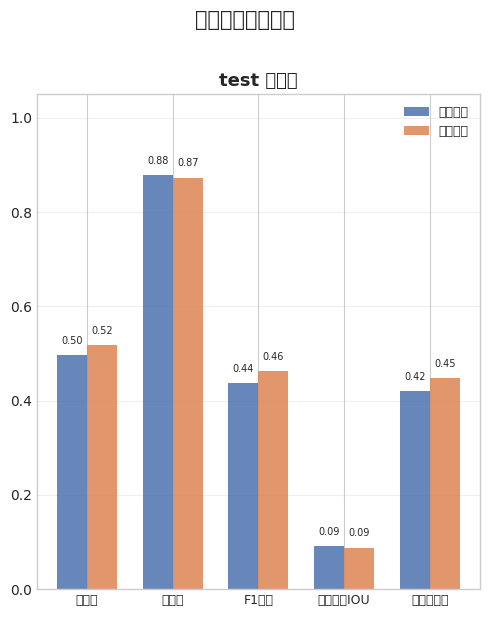

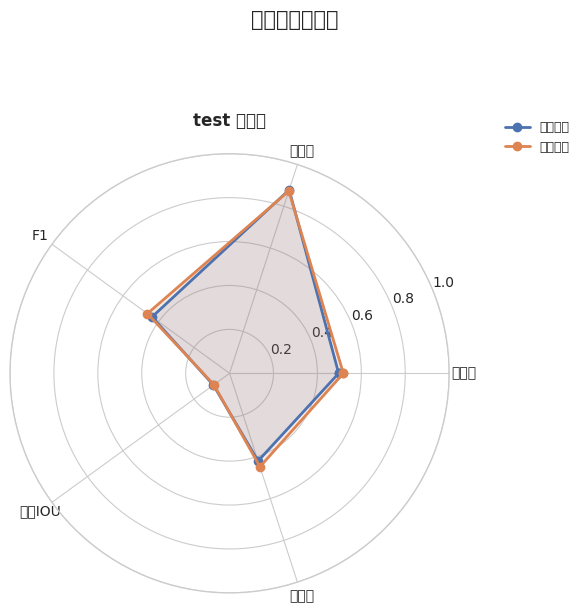

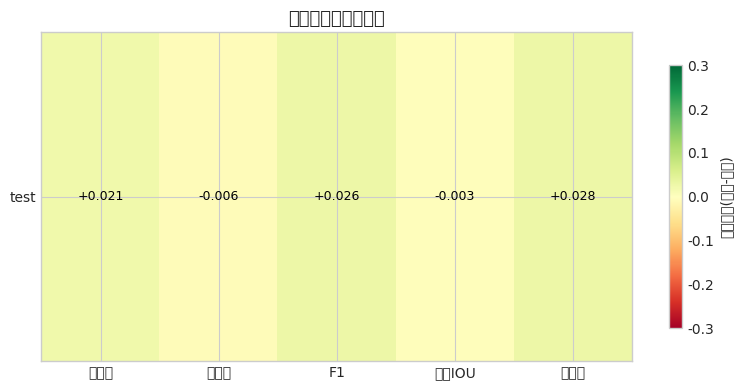

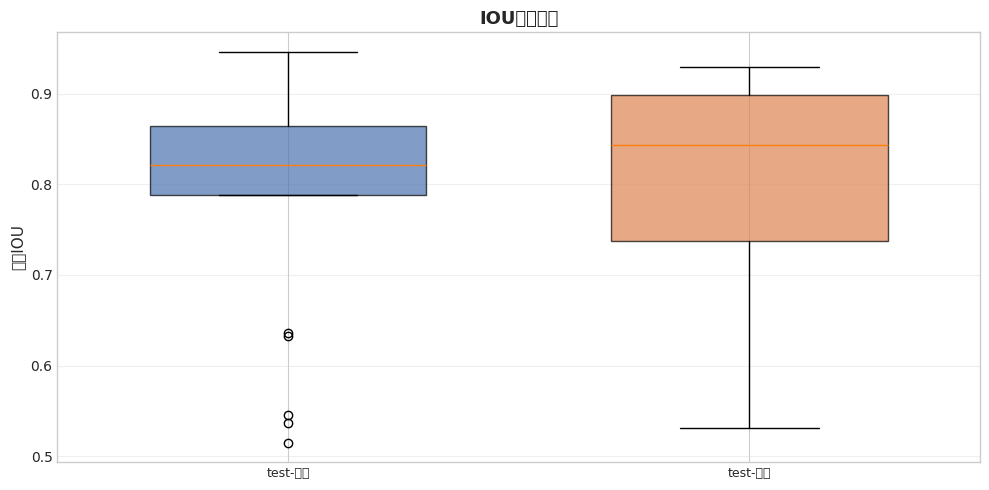

In [12]:
if all_metrics:
    try:
        plt.style.use(CHART_STYLE)
    except Exception:
        pass

    metrics_visualizer.plot_metrics_bar_chart(all_metrics, "模型性能分组对比")
    metrics_visualizer.plot_radar_chart(all_metrics, "模型性能雷达图")
    metrics_visualizer.plot_diff_heatmap(all_metrics)

    if all_results:
        metrics_visualizer.plot_iou_distribution(all_results)
else:
    print("暂无评估结果, 请先运行批量评估")

## 12. 差异分析与总结

自动分析微调模型的关键改进点和潜在退化，生成结构化分析报告。

In [13]:
def generate_analysis(all_metrics: Dict) -> str:
    """自动生成差异分析报告"""
    if not all_metrics:
        return "暂无评估结果"

    report_lines = []
    report_lines.append("=" * 60)
    report_lines.append("微调效果差异分析报告")
    report_lines.append("=" * 60)
    report_lines.append(f"\n生成时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    report_lines.append(f"IOU匹配阈值: {IOU_MATCH_THRESHOLD}")
    report_lines.append("")

    # 1. 总体改进分析
    report_lines.append("一、总体改进分析")
    report_lines.append("-" * 40)

    all_improvements = []
    all_degradations = []

    for split_name in ["train", "valid", "test"]:
        if split_name not in all_metrics:
            continue
        base = all_metrics[split_name].get("base", {})
        ft = all_metrics[split_name].get("finetuned", {})

        metric_names = {
            "mean_precision": "精确率",
            "mean_recall": "召回率",
            "mean_f1": "F1分数",
            "mean_mean_match_iou": "匹配IOU",
            "success_rate": "检测成功率",
        }

        report_lines.append(f"\n  [{split_name} 数据集]")
        for key, label in metric_names.items():
            base_val = base.get(key, 0)
            ft_val = ft.get(key, 0)
            diff = ft_val - base_val
            if diff > 0.01:
                report_lines.append(f"    + {label}: {base_val:.3f} -> {ft_val:.3f} (提升 {diff:+.3f})")
                all_improvements.append((split_name, label, diff))
            elif diff < -0.01:
                report_lines.append(f"    - {label}: {base_val:.3f} -> {ft_val:.3f} (退化 {diff:+.3f})")
                all_degradations.append((split_name, label, diff))
            else:
                report_lines.append(f"    = {label}: {base_val:.3f} -> {ft_val:.3f} (持平)")

    # 2. 关键发现
    report_lines.append("\n\n二、关键发现")
    report_lines.append("-" * 40)

    if all_improvements:
        top_improvements = sorted(all_improvements, key=lambda x: x[2], reverse=True)[:3]
        report_lines.append("\n  最显著改进:")
        for split, label, diff in top_improvements:
            report_lines.append(f"    - {split}数据集的{label}: 提升{diff:+.3f}")

    if all_degradations:
        top_degradations = sorted(all_degradations, key=lambda x: x[2])[:3]
        report_lines.append("\n  需关注退化:")
        for split, label, diff in top_degradations:
            report_lines.append(f"    - {split}数据集的{label}: 退化{diff:+.3f}")

    # 3. 泛化能力分析
    report_lines.append("\n\n三、泛化能力分析")
    report_lines.append("-" * 40)

    splits_available = [s for s in ["train", "valid", "test"] if s in all_metrics]
    if len(splits_available) >= 2:
        train_ft = all_metrics.get("train", {}).get("finetuned", {}).get("mean_f1", 0)
        test_ft = all_metrics.get("test", {}).get("finetuned", {}).get("mean_f1", 0)
        valid_ft = all_metrics.get("valid", {}).get("finetuned", {}).get("mean_f1", 0)

        train_base = all_metrics.get("train", {}).get("base", {}).get("mean_f1", 0)
        test_base = all_metrics.get("test", {}).get("base", {}).get("mean_f1", 0)

        ft_gap = train_ft - test_ft if train_ft and test_ft else 0
        base_gap = train_base - test_base if train_base and test_base else 0

        report_lines.append(f"\n  微调模型 F1: train={train_ft:.3f}, valid={valid_ft:.3f}, test={test_ft:.3f}")
        report_lines.append(f"  原始模型 F1: train={train_base:.3f}, test={test_base:.3f}")
        report_lines.append(f"\n  微调模型 train-test差距: {ft_gap:+.3f}")
        report_lines.append(f"  原始模型 train-test差距: {base_gap:+.3f}")

        if ft_gap < base_gap:
            report_lines.append("\n  结论: 微调模型的泛化差距更小, 泛化能力更优")
        elif ft_gap > base_gap:
            report_lines.append("\n  结论: 微调模型的泛化差距更大, 可能存在过拟合风险")
        else:
            report_lines.append("\n  结论: 两个模型的泛化差距相近")

    # 4. 建议
    report_lines.append("\n\n四、后续优化建议")
    report_lines.append("-" * 40)
    if all_degradations:
        report_lines.append("  - 关注退化指标, 考虑调整训练数据分布或LoRA参数")
    report_lines.append("  - 增加IOU阈值(0.5->0.7)可更严格评估定位精度")
    report_lines.append("  - 可按类别分别统计指标, 找出薄弱类别针对性优化")

    return "\n".join(report_lines)


analysis_report = generate_analysis(all_metrics)
print(analysis_report)

微调效果差异分析报告

生成时间: 2026-05-14 07:41:12
IOU匹配阈值: 0.5

一、总体改进分析
----------------------------------------

  [test 数据集]
    + 精确率: 0.497 -> 0.518 (提升 +0.021)
    = 召回率: 0.878 -> 0.873 (持平)
    + F1分数: 0.437 -> 0.463 (提升 +0.026)
    = 匹配IOU: 0.091 -> 0.088 (持平)
    + 检测成功率: 0.420 -> 0.448 (提升 +0.028)


二、关键发现
----------------------------------------

  最显著改进:
    - test数据集的检测成功率: 提升+0.028
    - test数据集的F1分数: 提升+0.026
    - test数据集的精确率: 提升+0.021


三、泛化能力分析
----------------------------------------


四、后续优化建议
----------------------------------------
  - 增加IOU阈值(0.5->0.7)可更严格评估定位精度
  - 可按类别分别统计指标, 找出薄弱类别针对性优化


---

## Notebook 完成总结

本 Notebook 实现了以下功能:

1. **数据集加载**: 从 JSONL 格式加载 train/valid/test 三个数据集
2. **Ground Truth 解析**: 从训练数据的 assistant 消息中提取边界框坐标
3. **批量推理**: 对每条记录分别用原始模型和微调模型执行推理
4. **指标计算**: 精确率、召回率、F1、匹配IOU、检测成功率
5. **结果展示**: 文本表格 + 改进幅度表格
6. **可视化对比**: 分组柱状图、雷达图、热力图、IOU分布箱线图
7. **差异分析**: 自动识别关键改进点和退化风险

验证过程可重复 -- 只需修改配置参数即可重新运行全流程。